# Pipeline notebook

En este notebook estará todo el pipeline desde los datos en crudo hasta la clusterización.

## Data Preprocessing

Pre process de todos los datos, los uniremos en un unico data frame 

In [2]:
import pandas as pd
from pathlib import Path
import glob


from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import time
from geopy.geocoders import Nominatim

In [2]:
entries_all = pd.DataFrame()

In [3]:
for excel_file in Path('./raw_csv_per_year').glob('*.xlsx'):
    conc = pd.read_excel(excel_file)
    
    entries_all = pd.concat([entries_all,conc])
    print(excel_file)
entries_all

raw_csv_per_year/2021.xlsx
raw_csv_per_year/2017.xlsx
raw_csv_per_year/2016.xlsx
raw_csv_per_year/2020.xlsx
raw_csv_per_year/2011.xlsx
raw_csv_per_year/2010.xlsx
raw_csv_per_year/2013.xlsx
raw_csv_per_year/2012.xlsx
raw_csv_per_year/2019.xlsx
raw_csv_per_year/2015.xlsx
raw_csv_per_year/2014.xlsx
raw_csv_per_year/2022.xlsx
raw_csv_per_year/2018.xlsx


,Entrada,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,2021-01/0001-01,2021-01-01 10:24:45,M,38,Europa,Portugal,NaN,Pie,Religioso y otros,Costa Camino Portugues,Vigo,Parados
1,2021-01/0001-02,2021-01-01 10:24:45,M,36,Europa,España,Galicia,Pie,Religioso y otros,Frances-Camino de,Sarria,Liberales
2,2021-01/0001-03,2021-01-01 10:24:45,M,40,Europa,Rumania,NaN,Pie,Religioso,Frances-Camino de,Sarria,Deportistas
3,2021-01/0001-04,2021-01-01 10:24:45,M,80,Europa,España,Castilla León,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
4,2021-01/0001-05,2021-01-01 10:24:45,M,36,Europa,España,Madrid,Pie,Religioso y otros,Frances-Camino de,Vilafranca,Artistas
...,...,...,...,...,...,...,...,...,...,...,...,...
327362,2018-12/16494-16,2018-12-31 00:00:00,M,42,América del Sur,Venezuela,NaN,Pie,Religioso,Frances-Camino de,Sarria,Liberales
327363,2018-12/16494-17,2018-12-31 00:00:00,F,57,Europa,Portugal,NaN,Pie,Religioso,Ingles-Camino,A Coruña,Profesores
327364,2018-12/16494-18,2018-12-31 00:00:00,F,48,Europa,Portugal,NaN,Pie,Religioso y otros,Ingles-Camino,A Coruña,Profesores
327365,2018-12/16494-19,2018-12-31 00:00:00,F,31,Europa,Ucrania,NaN,Pie,Religioso,Via de la Plata,Ourense,Liberales


In [4]:
entries_all = entries_all.sort_values(by= 'Fecha', ascending=True)
entries_all = entries_all.sort_values(by= 'Entrada', ascending=True)
entries_all = entries_all.drop(columns='Entrada')

### Limpieza columna a columna 

### 1. Sexo

In [5]:
entries_all.Sexo.value_counts()

M    1708754
F    1579895
D          1
0          1
Name: Sexo, dtype: int64

In [6]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Sexo'] == 'D'].index)
entries_all = entries_all.drop(entries_all.loc[entries_all['Sexo'] == '0'].index)
entries_all.Sexo.value_counts()

M    1708746
F    1579892
Name: Sexo, dtype: int64

### 2. Edad

<Axes: >

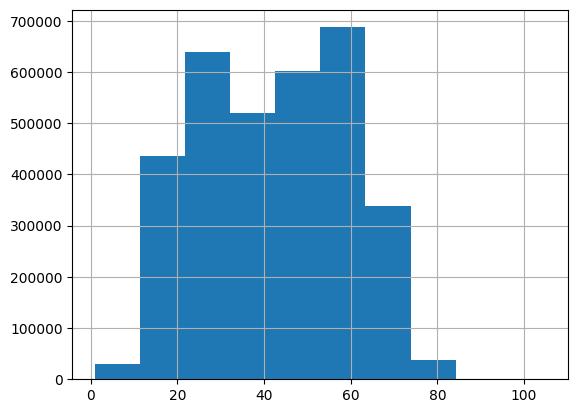

In [7]:
entries_all.Edad.hist()

In [8]:
entries_all.Edad.min()


1

In [9]:
entries_all.Edad.max()



105

 ### 3. Continente

In [10]:
entries_all[entries_all.Continente.isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
62492,2021-08-07 18:23:31,M,29,NaN,NaN,NaN,Pie,Religioso y otros,Ingles-Camino,Ferrol,NaN


### 4. País

In [11]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Pais'].isna()]. index)

### 5. Autonomía 

In [12]:
entries_all.Autonomia.value_counts()

Andalucía                317440
Madrid                   311813
Residentes Extranjero    235366
Comunidad Valenciana     189557
Cataluña                 177802
Galicia                  143460
Castilla León             93322
Castilla la Mancha        87304
Pais Vasco                59861
Canarias                  48521
Murcia                    46560
Extremadura               46518
Aragón                    34244
Asturias                  32547
Baleares                  23534
Navarra                   16285
Cantabria                 13706
La Rioja                   7799
Ceuta                      2468
Melilla                    1544
Name: Autonomia, dtype: int64

In [13]:
mask_naaut = entries_all.Autonomia.isna()
mask_esp = entries_all['Pais'] == 'España'
entries_all[mask_naaut & mask_esp]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
1081,2010-01-30 00:00:00,F,27,Europa,España,NaN,Pie,Religioso,Frances-Camino de,Cebreiro,Empleados
1736,2010-02-15 00:00:00,M,28,Europa,España,NaN,Pie,No religioso,Portugues-Camino,Tui,Liberales
1737,2010-02-15 00:00:00,M,23,Europa,España,NaN,Pie,Religioso y otros,Portugues-Camino,Tui,Estudiantes
6392,2010-03-26 00:00:00,M,25,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Logroño,Liberales
8008,2010-03-31 00:00:00,F,17,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Sarria,Estudiantes
...,...,...,...,...,...,...,...,...,...,...,...
126318,2019-06-23 00:00:00,M,40,Europa,España,NaN,Pie,Religioso,Portugues-Camino,Tui,Empleados
126383,2019-06-23 00:00:00,F,40,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Cebreiro,Liberales
126390,2019-06-23 00:00:00,M,33,Europa,España,NaN,Pie,Religioso,Frances-Camino de,Sarria,Liberales
126431,2019-06-23 00:00:00,F,22,Europa,España,NaN,Pie,Religioso y otros,Frances-Camino de,Sarria,Estudiantes


In [14]:
mascara = mask_esp & mask_naaut
entries_all.loc[mascara, 'Autonomia'] = 'Otra'

In [15]:
mask_noesp =  entries_all['Pais'] != 'España'
mask_nonan = entries_all['Autonomia'].notna()

In [16]:
entries_all[mask_noesp & mask_nonan]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
3346,2010-03-10 00:00:00,F,27,América del Norte,Estados Unidos,Cataluña,Pie,Religioso y otros,Frances-Camino de,S. Jean P. Port,Liberales
3419,2010-03-11 00:00:00,M,33,Europa,Alemania,Baleares,Pie,Religioso,Frances-Camino de,León,Empleados
3429,2010-03-11 00:00:00,F,32,Oceanía,Nueva Zelanda,Castilla León,Pie,Religioso y otros,Portugues-Camino,Valença do Minho,Empleados
3634,2010-11-30 00:00:00,M,32,América del Norte,Canadá,Andalucía,Pie,Religioso,Frances-Camino de,Francia - C.F.,Profesores
3760,2010-03-14 00:00:00,F,25,América del Norte,Estados Unidos,Asturias,Pie,Religioso y otros,Frances-Camino de,León,Liberales
...,...,...,...,...,...,...,...,...,...,...,...
437893,2022-12-31 16:45:23,M,56,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437894,2022-12-31 16:45:23,M,55,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437895,2022-12-31 16:45:23,M,28,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN
437896,2022-12-31 16:45:23,M,16,Europa,Portugal,Residentes Extranjero,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,NaN


Estos son o Españoles residentes en el extranjero o extranjeros residentes en España.

### 6. Medio

In [17]:
entries_all[entries_all.Medio.isna()]
entries_all.Medio.value_counts()

Pie                2988069
Bicicleta           291612
Caballo               6956
Vela                  1176
Silla de ruedas        813
Name: Medio, dtype: int64

In [18]:
entries_all.loc[entries_all['Medio'] == 'Vela', 'Origen'].unique()

array(['Resto de Galicia', 'Zamora', 'Sevilla', 'S. Jean P. Port',
       'Valença do Minho', 'Roncesvalles', 'Oviedo - C.P.', 'Sarria',
       'Gijón', 'Viveiro', 'Santander', 'Resto País Vasco - C.N.',
       'Resto Asturias - C.N', 'Resto Galicia', 'Ribadeo', 'Bilbao',
       'Viana do Castelo', 'Reino Unido C.Ing', 'Francia - C.N', 'Ferrol',
       'Resto Portugal', 'Hendaya', 'Le Puy', 'Tui', 'Oporto Costa',
       'Irlanda C. Ing', 'Baiona', 'Francia - C.F.', 'Ourense',
       'Resto Cantabria', 'A Coruña', 'Povoa de Varzim', 'Logroño',
       'Holanda', 'Burgos', 'Ponferrada', 'Oporto', 'Chaves-Portugal',
       'Astorga', 'Rates, S. Pedro', 'Lisboa', 'León', 'Vigo',
       'Cataluña - O.C.', 'Muxia', 'A Guarda', 'Castilla la Mancha otros',
       'Valencia O.C.', 'Salamanca', 'C.G.A resto de Portugal',
       'Resto Andalucia', 'Lagos', 'Tavira', 'Muros', 'Porto do Son',
       'Ribadeo C. del Mar', 'Laredo', 'San Sebastián', 'Resto Europa',
       'Fazouro', 'Italia', 'Irún', 

No sabemos si se refiere ruta maritima o terrestre? 

### 7. Motivo 

In [19]:
entries_all.Motivo.unique()

array(['Religioso', 'Religioso y otros', 'No religioso'], dtype=object)

### 8. Camino

In [20]:
entries_all.loc[entries_all['Camino'] == 'Costa Camino Portugues  ', 'Camino'] = 'Costa Camino Portugues'

### 9. Origen

In [21]:
entries_all.Origen.unique()

array(['Resto Cantabria', 'Sarria', 'Ponferrada', 'Astorga', 'Braga',
       'Ourense', 'Pamplona', 'Tui', 'Lugo - C.P.', 'Roncesvalles',
       'Resto C. León C.F.', 'Laza', 'Valença do Minho', 'Cebreiro',
       'Ferrol', 'Irún', 'León', 'Holanda', 'Oporto', 'Triacastela',
       'Logroño', 'Suiza', 'Oviedo - C.P.', 'S. Jean P. Port', 'Frómista',
       'Vilafranca', 'Burgos', 'Resto Asturias - C.N', 'Francia - C.F.',
       'Sevilla', 'Castilla La Mancha VP', 'Ribadeo', 'Jaca',
       'Granja de Moreruela', 'Alemania', 'Carrión de los Condes',
       'Somport', 'Abadin', 'Resto Andalucia', 'Oviedo - C.N.', 'Vilalba',
       'Lourenzá', 'Avilés', 'Le Puy', 'Barcelona', 'Madrid - C.F.',
       'Salamanca', 'Francia - C.N', 'Sto. Domingo de la Calzada',
       'Cadavo', 'Samos', 'Zamora', 'Murcia', 'Xunqueira de Ambia',
       'Com. Valenciana - C.F.', 'Polonia', 'Lourdes', 'Cáceres',
       'Hospital de Orbigo', 'Reino Unido C.F.', 'Resto Portugal',
       'París', 'Verín', 'Santander

In [22]:
entries_all['Origen'] = [s.replace("Cast." , "Castilla") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Resto " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.F." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - V.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.N" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - C.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" Com." , "Comunidad") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.G.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.G.R." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.M.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("(por Pobra de Burón)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por San Xoán de Padrón )" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por Samos)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por San XII)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C. León C.F." , "Castilla León") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" - O.C." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C. Ing" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.Ing" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("La Mesa" , "La Mesa, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Hospital, España de Orbigo" , "Hospital, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.F." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" C.Inv." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" V.P." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A. resto de " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.R." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("O.C." , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.A" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("C.G.R" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Portugal C.M.R." , "Portugal") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("R.Pais Vasco" , "Pais Vasco") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("otros" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("R. Castilla León C.Inv" , "Reino de Castilla y León") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Extremadura" , "Extremadura") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("de Portugal" , "Portugal") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("La caridad" , "La caridad, España") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" resto " , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace(" (por Tui)" , "") for s in entries_all.Origen]
entries_all['Origen'] = [s.replace("Vilanova de Cerveira" , "Gondarém") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Cadavelo" , "Cadavéu") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santa María de Gondar" , "Gondar, Portugal") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santa Marta de Tara" , "Santa Marta de Tera") for s in entries_all.Origen]

entries_all['Origen'] = [s.replace("Santiago da ria de abres" , "A ria de abres") for s in entries_all.Origen]





#### Añadimos Latitud y Longitud

In [23]:

loc = Nominatim(user_agent="GetLoc")
 
# entering the location name
getLoc = loc.geocode("La Mesa, España")
 
# printing address
print(getLoc.address)
 
# printing latitude and longitude
print("Latitude = ", getLoc.latitude)
print("Longitude = ", getLoc.longitude)

La Mesa, Merindad de Sotoscueva, Burgos, Castilla y León, España
Latitude =  43.0246721
Longitude =  -3.6426042


In [24]:
cache = {}
cache2 = {}

In [25]:
loc = Nominatim(user_agent="GetLoc")



In [28]:
def latitude(texto):
    if texto in cache:
        return cache[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            latitud = getLoc.latitude
            cache[texto] = latitud
            return latitud
        else:
            return None
    except:
        return None


In [29]:
def longitud(texto):
    if texto in cache2:
        return cache2[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            longitude = getLoc.longitude
            cache2[texto] = longitude
            return longitude
        else:
            return None
    except:
        return None

In [28]:
unique_vals = entries_all['Origen'].unique()
vals = unique_vals[entries_all['Origen'].value_counts() <200 ]

print(unique_vals)

['Cantabria' 'Sarria' 'Ponferrada' 'Astorga' 'Braga' 'Ourense' 'Pamplona'
 'Tui' 'Lugo' 'Roncesvalles' 'Castilla León' 'Laza' 'Valença do Minho'
 'Cebreiro' 'Ferrol' 'Irún' 'León' 'Holanda' 'Oporto' 'Triacastela'
 'Logroño' 'Suiza' 'Oviedo' 'S. Jean P. Port' 'Frómista' 'Vilafranca'
 'Burgos' 'Asturias' 'Francia' 'Sevilla' 'Castilla La Mancha VP' 'Ribadeo'
 'Jaca' 'Granja de Moreruela' 'Alemania' 'Carrión de los Condes' 'Somport'
 'Abadin' 'Andalucia' 'Oviedo.' 'Vilalba' 'Lourenzá' 'Avilés' 'Le Puy'
 'Barcelona' 'Madrid' 'Salamanca' 'Sto. Domingo de la Calzada' 'Cadavo'
 'Samos' 'Zamora' 'Murcia' 'Xunqueira de Ambia' 'Com. Valenciana'
 'Polonia' 'Lourdes' 'Cáceres' 'Hospital de Orbigo' 'Reino Unido'
 'Portugal' 'París' 'Verín' 'Santander' 'Bilbao' 'Lisboa' 'Finisterra'
 'Estella' 'C. León' 'Ponte de Lima' 'Vega de Valcarce' 'Sahagún'
 'Canfranc' 'Vigo' 'Huelva' 'Malaga' 'Fonsagrada' 'Tineo' 'País Vasco.'
 'Valladolid' 'Cataluña' 'Montserrat' 'Puente la Reina'
 'Puebla de Sanabria' 'Chav

In [30]:
for ele in unique_vals:
    inicio = time.time()
    latitude(ele)
    longitud(ele)
    print(ele)
    fin = time.time()
    print(fin-inicio)

Cantabria
0.8587169647216797
Sarria
0.9018611907958984
Ponferrada
1.043781042098999
Astorga
1.0233490467071533
Braga
0.8984389305114746
Ourense
1.0474529266357422
Pamplona
1.0246601104736328
Tui
1.0231330394744873
Lugo
1.021894931793213
Roncesvalles
0.8953092098236084
Castilla León
1.0499069690704346
Laza
1.0261881351470947
Valença do Minho
0.9065229892730713
Cebreiro
1.039184808731079
Ferrol
1.0239849090576172
Irún
1.0238220691680908
León
1.0239408016204834
Holanda
0.9096150398254395
Oporto
1.0359082221984863
Triacastela
1.022381067276001
Logroño
1.0251400470733643
Suiza
0.9254970550537109
Oviedo
1.0190982818603516
S. Jean P. Port
1.1017029285430908
Frómista
0.9481420516967773
Vilafranca
1.002434253692627
Burgos
0.9428000450134277
Asturias
1.0239708423614502
Francia
1.0240576267242432
Sevilla
0.9200079441070557
Castilla La Mancha VP
1.0336289405822754
Ribadeo
1.0125799179077148
Jaca
1.0268869400024414
Granja de Moreruela
0.929095983505249
Alemania
1.1186232566833496
Carrión de los Con

Lagos
1.024446964263916
Colombres
0.9404640197753906
Puerto de Béjar
0.9795629978179932
La Casquita
2.719106912612915
Dax
0.572484016418457
Faramontanos de Tábara
1.0344839096069336
Boadilla del Camino
1.0246410369873047
Espinosa del Camino
1.0236291885375977
Trabadelo
0.9206948280334473
Burdeos
1.0245311260223389
Puente Villarente
1.023759126663208
Roermond
1.024280071258545
Puente de Castro
1.026757001876831
Ribadeo C. del Mar
1.328268051147461
Sintra
0.6144728660583496
Lédigos
1.0240528583526611
Nigrán
1.0239791870117188
Ramallosa
0.9230704307556152
Ponte da Xira
1.022305965423584
As Gándaras de Budiño
1.0257477760314941
Reliegos
1.0253970623016357
Wien, Viena
0.9133379459381104
Grândola
1.0295500755310059
Cadavéu
1.0238189697265625
Padornelo
0.9502279758453369
Liñares
1.0963339805603027
Ponte do Porto (Mañón)
0.9229569435119629
Zafra
1.02382493019104
Burguete
1.0241892337799072
Morgade
1.023772954940796
Guemes
1.0050921440124512
Pola de Siero
0.9389760494232178
Sangüesa
1.025348186

In [31]:
len(cache)

478

In [32]:
def add_coords_to_dataframe(df, lat_dict, long_dict):
    df['Latitud'] = df['Origen'].map(lat_dict)
    df['Longitud'] = df['Origen'].map(long_dict)
    return df


In [33]:
entries_all = add_coords_to_dataframe(entries_all, cache, cache2)


In [34]:
limpeza = entries_all.loc[entries_all['Latitud'].isna(), 'Origen'].unique()
limpeza

array(['El Cubo de la Tierra del Vino'], dtype=object)

In [35]:
entries_all[entries_all['Latitud'].isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud
282959,2022-08-23 18:48:03,M,69,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282960,2022-08-23 18:48:03,M,43,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282961,2022-08-23 18:48:04,M,39,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282962,2022-08-23 18:48:04,M,53,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282963,2022-08-23 18:48:04,M,30,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282964,2022-08-23 18:48:04,M,30,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
282965,2022-08-23 18:48:04,M,53,Europa,España,Andalucía,Bicicleta,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN
398726,2022-10-14 14:24:23,M,66,Europa,España,Galicia,Pie,Religioso,Via de la Plata,El Cubo de la Tierra del Vino,NaN,NaN,NaN


In [36]:
entries_all = entries_all.drop(entries_all.loc[entries_all['Latitud'].isna()]. index)

In [37]:
entries_all[entries_all['Longitud'].isna()]

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud


### 10. Profesion

In [38]:
entries_all.Profesion = entries_all.Profesion.fillna('Otros')

In [39]:
entries_all.Profesion.unique()

array(['Jubilados', 'Liberales', 'Tecnicos', 'Empleados', 'Profesores',
       'Estudiantes', 'Agricultores', 'Obreros', 'Funcionarios',
       'Sacerdotes', 'Amas de Casa', 'Parados', 'Directivos',
       'Religiosas/os', 'Artistas', 'Deportistas', 'Marinos', 'Otros'],
      dtype=object)

In [40]:
entries_all.reset_index(drop=True, inplace=True)

#### Hecha la limpieza
Guardamos el resultado 

In [41]:
filepath = Path('Treated_csv/entries_all.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
entries_all.to_csv(filepath, index=False)


In [126]:
entries_all = pd.read_csv('Treated_csv/entries_all.csv')

In [127]:
entries_all['Fecha'] = pd.to_datetime(entries_all['Fecha'], format='%Y-%m-%d')



In [128]:
entries_all['Año'] = entries_all['Fecha'].dt.year
entries_all['Mes'] = entries_all['Fecha'].dt.month
entries_all['Dia'] = entries_all['Fecha'].dt.day
entries_all['Dialv'] = entries_all['Fecha'].dt.day_name()
entries_all.head()


,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday


## Preparamos el dataset para Clusterizar

#### 1. Añadimos las columnas que nos parecen interesantes 

In [197]:
paclust = entries_all.copy()

In [198]:
paclust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288597 entries, 0 to 3288596
Data columns (total 17 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Fecha       datetime64[ns]
 1   Sexo        object        
 2   Edad        int64         
 3   Continente  object        
 4   Pais        object        
 5   Autonomia   object        
 6   Medio       object        
 7   Motivo      object        
 8   Camino      object        
 9   Origen      object        
 10  Profesion   object        
 11  Latitud     float64       
 12  Longitud    float64       
 13  Año         int64         
 14  Mes         int64         
 15  Dia         int64         
 16  Dialv       object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(10)
memory usage: 426.5+ MB


In [199]:
paclust['Fecha'] = pd.to_datetime(paclust['Fecha'], format='%Y-%m-%d')


In [200]:
paclust['Año'] = paclust['Fecha'].dt.year
paclust['Mes'] = paclust['Fecha'].dt.month
paclust['Dia'] = paclust['Fecha'].dt.day
paclust['Dialv'] = paclust['Fecha'].dt.day_name()
paclust.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday


In [201]:
paclust.Profesion.unique()

array(['Jubilados', 'Liberales', 'Tecnicos', 'Empleados', 'Profesores',
       'Estudiantes', 'Agricultores', 'Obreros', 'Funcionarios',
       'Sacerdotes', 'Amas de Casa', 'Parados', 'Directivos',
       'Religiosas/os', 'Artistas', 'Deportistas', 'Marinos', 'Otros'],
      dtype=object)

In [202]:
paclust['ProfesionS'] = paclust['Profesion']

In [203]:
# Reemplazar los valores de la columna "Profesion" correspondientes a las categorías "Empleados", "Funcionarios", "Tecnicos", "Agricultores", "Obreros" y "Marinos" por el valor "Trabajadores"
paclust['ProfesionS'] = paclust['ProfesionS'].replace(['Empleados', 'Funcionarios', 'Tecnicos', 'Agricultores', 'Obreros', 'Marinos', 'Profesores'], 'Trabajadores')
paclust['ProfesionS'] = paclust['ProfesionS'].replace(['Sacerdotes'], 'Religiosas/os')


In [204]:
paclust.ProfesionS.unique()



array(['Jubilados', 'Liberales', 'Trabajadores', 'Estudiantes',
       'Religiosas/os', 'Amas de Casa', 'Parados', 'Directivos',
       'Artistas', 'Deportistas', 'Otros'], dtype=object)

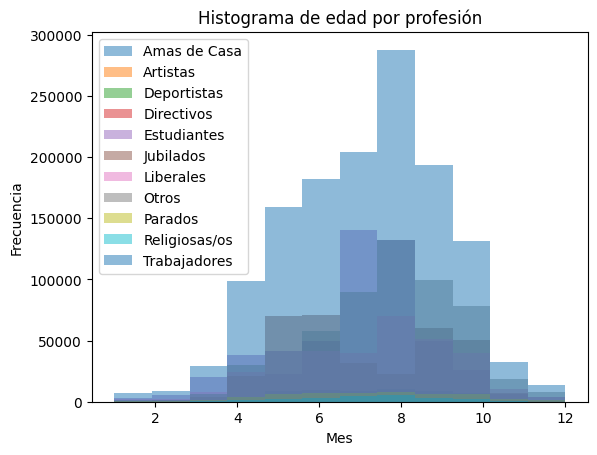

In [205]:

# Agrupar los datos por la columna "Profesion"
grouped = paclust.groupby('ProfesionS')

# Trazar el histograma de edad para cada grupo
for profession, group in grouped:
    plt.hist(group['Mes'], bins=12, alpha=0.5, label=profession)

    # Configurar las etiquetas del eje x y el título del gráfico
    plt.xlabel('Mes')
    plt.ylabel('Frecuencia')
    plt.title('Histograma de edad por profesión')

    # Mostrar la leyenda y el gráfico
    plt.legend()
    #plt.show()


### Añadir etapas y origenes

In [206]:
etaps = pd.read_excel('Caminos con etapas 2.xlsx', header= 2)
etaps = etaps.rename(columns={'Ciudad': 'Origen'})


etaps.head(2)

,Camino,Etapa,Origen,km
0,Frances,0,Santiago de Compostela,0.0
1,Frances,1,O Pedrouzo,19.4


In [207]:
def limpiar_columna(df, columna):
    df[columna] = df[columna].apply(lambda x: x.rstrip())
    return df



In [209]:
limpiar_columna(etaps,'Origen').head()

,Camino,Etapa,Origen,km
0,Frances,0,Santiago de Compostela,0.0
1,Frances,1,O Pedrouzo,19.4
2,Frances,2,Arzúa,19.3
3,Frances,3,Palas de Rei,28.5
4,Frances,4,Portomarín,24.8


In [210]:
paclust['Camino'] = [s.replace("-Camino de" , "") for s in paclust.Camino]  
paclust['Camino'] = [s.replace("-Camino" , "") for s in paclust.Camino]  

paclust['Camino'] = [s.replace("Costa Camino Portugues" , "Portugués por la costa") for s in paclust.Camino]  




In [211]:
paclust['OrigenCamino'] = paclust['Origen'] + paclust['Camino']
etaps['OrigenCamino'] = etaps['Origen'] + etaps['Camino']



In [212]:
etap_dict = dict(zip(etaps['OrigenCamino'], etaps['Etapa']))
etap_dict

{'Santiago de CompostelaFrances': 0,
 'O PedrouzoFrances': 1,
 'ArzúaFrances': 2,
 'Palas de ReiFrances': 3,
 'PortomarínFrances': 4,
 'SarriaFrances': 5,
 'TriacastelaFrances': 6,
 'O CebreiroFrances': 7,
 'Villafranca Del BierzoFrances': 8,
 'PonferradaFrances': 9,
 'FoncebadónFrances': 10,
 'AstorgaFrances': 11,
 'San Martín Del CaminoFrances': 12,
 'LeónFrances': 13,
 'Mansilla De Las MulasFrances': 14,
 'Bercianos Del Real CaminoFrances': 15,
 'Terradillos De Los TemplariosFrances': 16,
 'Carrión De Los CondesFrances': 17,
 'FrómistaFrances': 18,
 'CastrojerizFrances': 19,
 'Hornillos Del CaminoFrances': 20,
 'BurgosFrances': 21,
 'San Juan De OrtegaFrances': 22,
 'BeloradoFrances': 23,
 'Santo Domingo de La CalzadaFrances': 24,
 'NájeraFrances': 25,
 'LogroñoFrances': 26,
 'Los ArcosFrances': 27,
 'EstellaFrances': 28,
 'Puente la ReinaFrances': 29,
 'PamplonaFrances': 30,
 'ZubiriFrances': 31,
 'RoncesvallesFrances': 32,
 'Saint Jean Pied de PortFrances': 33,
 'Santiago de Compo

In [213]:
paclust['Etapa'] = paclust['OrigenCamino'].map(etap_dict)

paclust.head(5)

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,ProfesionS,OrigenCamino,Etapa
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,Jubilados,CantabriaNorte,NaN
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,Jubilados,SarriaFrances,5.0
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,Liberales,PonferradaFrances,9.0
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday,Trabajadores,PonferradaFrances,9.0
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday,Trabajadores,AstorgaFrances,11.0


In [214]:
paclust = paclust.drop(columns = 'OrigenCamino', axis =1 )

In [215]:
paclust.Etapa.isna().value_counts()

False    2213302
True     1075295
Name: Etapa, dtype: int64

In [216]:
paclust.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,ProfesionS,Etapa
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,Jubilados,NaN
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,Jubilados,5.0
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,Liberales,9.0
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday,Trabajadores,9.0
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday,Trabajadores,11.0


# GUARDADO

In [193]:
filepath = Path('Treated_csv/paclust.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
paclust.to_csv(filepath, index=False)



#### 2. Eliminamos las columnas con las que no trabajaremos

In [217]:
paclust = paclust.drop(["Fecha", "Autonomia", "Medio", "Motivo", "Origen","Profesion", "Dia","Año","Etapa"], axis=1)

In [221]:
paclust.head()

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,58,43.159566,-4.087838,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,62,42.778420,-7.414661,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,54,42.545412,-6.593872,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,44,42.545412,-6.593872,1,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,64,42.455356,-6.052903,1,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


#### 3. Convertimos variables categoricas en numericas



#### 3.1 Dummies

In [55]:
paclust.ProfesionS.value_counts()

Trabajadores     1346791
Otros             565390
Estudiantes       497531
Jubilados         342777
Liberales         334896
Amas de Casa       62115
Parados            50610
Directivos         38798
Artistas           23924
Religiosas/os      22812
Deportistas         2953
Name: ProfesionS, dtype: int64

In [99]:
def do_onehot_encoding(df, cols):
    df = pd.get_dummies(df, columns=cols)
    return df


def undo_onehot_encoding(df, cols):
    for col in cols:
        prefix = col + '_'
        cat_cols = [c for c in df.columns if c.startswith(prefix)]
        col_values = df[cat_cols].idxmax(axis=1).apply(lambda x: x.split(prefix)[-1])
        df[col] = col_values
        df.drop(cat_cols, axis=1, inplace=True)
    return df


In [219]:
paclust = do_onehot_encoding(paclust, ["Sexo","ProfesionS","Pais","Camino","Continente","Dialv"])

In [58]:
paclust.head()

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,58,43.159566,-4.087838,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,62,42.778420,-7.414661,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,54,42.545412,-6.593872,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,44,42.545412,-6.593872,1,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,64,42.455356,-6.052903,1,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


#### 3.2 Count Encoding 

In [59]:
def count_encoding(df, cols):
    for col in cols:
        col_count = df[col].value_counts().to_dict()
        df[col+'_count'] = df[col].map(col_count)
    return df

def undo_count_encoding(df, cols):
    for col in cols:
        col_name = col.split('_count')[0]
        col_dict = df.groupby(col_name)[col].mean().to_dict()
        df[col_name] = df[col].map(col_dict)
        df.drop(col, axis=1, inplace=True)
    return df


#### 4. Escalamos las variables

In [222]:


def escala_col(df, cols):
    scaler = StandardScaler()
    df[cols] = scaler.fit_transform(df[cols])
    
    return df,scaler

def desescala_col(df, cols, scaler):
    df[cols] = scaler.inverse_transform(df[cols])
    
    return df

In [223]:
columnas = paclust.columns.to_list()
columnas = ['Edad','Latitud','Longitud', 'Mes']

In [224]:
paclust_scaled, scaler = escala_col(paclust, columnas)

In [225]:
paclust_scaled.head()

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,0.937955,0.244722,0.330714,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,1.175386,0.188674,0.053846,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,0.700524,0.154410,0.122155,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,0.106946,0.154410,0.122155,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,1.294101,0.141167,0.167176,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


In [226]:
correlation_matrix = paclust_scaled.corr()


In [227]:
correlation_matrix

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
Edad,1.000000,-0.045781,-0.017750,0.013137,-0.038152,0.038152,0.102311,-0.002662,-0.006389,0.031861,...,-0.104361,0.064657,0.019967,-0.019564,0.011810,0.000874,0.004588,-0.005115,0.010894,0.000387
Latitud,-0.045781,1.000000,0.949386,0.004475,0.047501,-0.047501,-0.000961,-0.000234,-0.000724,0.003140,...,-0.017763,0.006184,0.003663,0.008828,-0.003805,0.002568,0.000492,-0.001967,-0.004684,-0.003531
Longitud,-0.017750,0.949386,1.000000,0.007397,0.025418,-0.025418,-0.007238,0.007338,0.000355,0.005991,...,-0.049290,0.023111,0.007170,-0.002944,0.003999,-0.003232,0.001176,-0.003070,0.003402,0.001993
Mes,0.013137,0.004475,0.007397,1.000000,0.005884,-0.005884,-0.005586,0.002907,-0.001227,-0.006525,...,-0.009234,0.010084,-0.000413,-0.003950,0.006380,0.001705,0.002992,-0.004551,0.003616,-0.005445
Sexo_F,-0.038152,0.047501,0.025418,0.005884,1.000000,-1.000000,0.130460,-0.000002,-0.006597,-0.016346,...,-0.066366,0.028173,0.018618,0.002968,-0.002168,0.000334,-0.003444,0.001790,-0.002147,0.002125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dialv_Saturday,0.000874,0.002568,-0.003232,0.001705,0.000334,-0.000334,0.007076,-0.002825,0.001059,-0.001630,...,0.027017,-0.008316,-0.005129,-0.217916,-0.167027,1.000000,-0.190885,-0.187481,-0.166483,-0.172964
Dialv_Sunday,0.004588,0.000492,0.001176,0.002992,-0.003444,0.003444,0.004519,-0.000559,-0.000907,-0.002638,...,0.002067,-0.004197,0.000033,-0.195386,-0.149758,-0.190885,1.000000,-0.168097,-0.149270,-0.155081
Dialv_Thursday,-0.005115,-0.001967,-0.003070,-0.004551,0.001790,-0.001790,-0.004009,-0.000822,-0.001498,0.000324,...,-0.001052,0.000664,-0.000854,-0.191901,-0.147087,-0.187481,-0.168097,1.000000,-0.146607,-0.152315
Dialv_Tuesday,0.010894,-0.004684,0.003402,0.003616,-0.002147,0.002147,-0.001239,0.004721,0.000822,0.002513,...,-0.021707,0.006593,0.004194,-0.170408,-0.130613,-0.166483,-0.149270,-0.146607,1.000000,-0.135255


In [232]:

# creamos una lista con las columnas a eliminar
to_drop = []
for col in correlation_matrix.columns:
    if sum(correlation_matrix[col] > 0.50) < 2:
        to_drop.append(col)

# eliminamos las columnas de la matriz de correlación y del dataframe original
correlation_matrix = correlation_matrix.drop(to_drop, axis=0).drop(to_drop, axis=1)


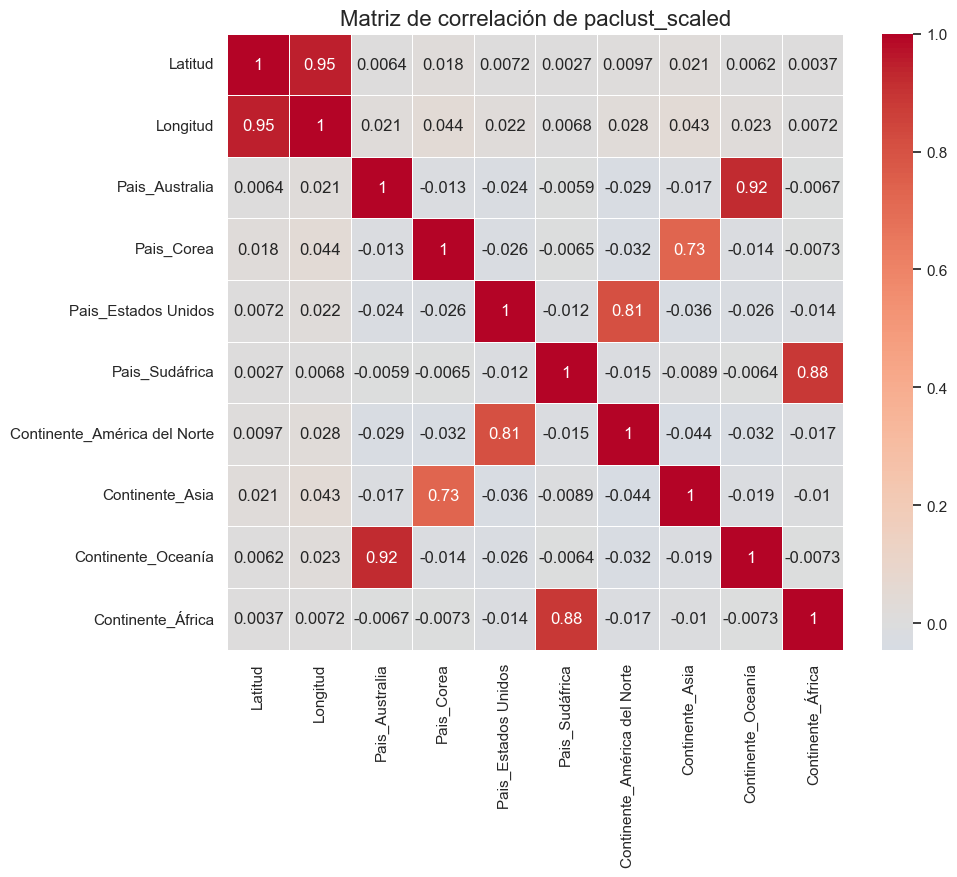

In [233]:


# Crear el heatmap
sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title("Matriz de correlación de paclust_scaled", fontsize=16)
plt.show()


<Axes: >

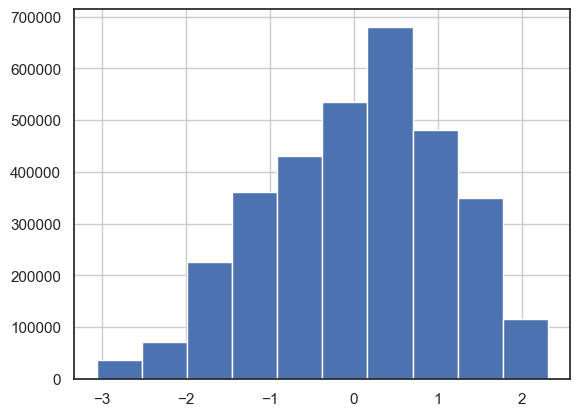

In [234]:
paclust_scaled.Mes.hist()

<Axes: >

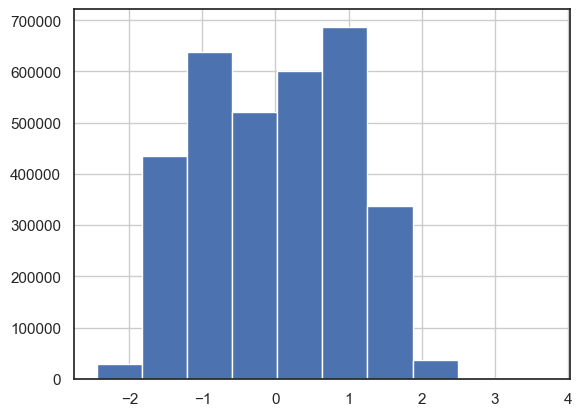

In [235]:
paclust_scaled.Edad.hist()

## Clusterizamos

In [285]:
paclust_scaled

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,0.937955,0.244722,0.330714,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,1.175386,0.188674,0.053846,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,0.700524,0.154410,0.122155,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,0.106946,0.154410,0.122155,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,1.294101,0.141167,0.167176,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288592,0.819239,-0.409922,-0.089458,2.312402,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3288593,0.759881,-0.409922,-0.089458,2.312402,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3288594,-0.842777,-0.409922,-0.089458,2.312402,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3288595,-1.555070,-0.409922,-0.089458,2.312402,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [237]:
distortions = []                                                  
K = range(2, 7)                                                  

name = "k-means++"

for k in K:
    kmeanModel = KMeans(init="k-means++", n_clusters=k,random_state=42)
    t0 = time.time()
    kmeanModel.fit(paclust_scaled)
    fit_time = time.time() - t0
    results = [name, fit_time, kmeanModel.inertia_]
    print('Results:  Name: ',results[0],'  Time: ', results[1],'   Inertia: ', results[2])
    distortions.append(kmeanModel.inertia_)    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  49.560585260391235    Inertia:  19097283.829973593


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  74.78160309791565    Inertia:  16562164.91859047


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  80.89847111701965    Inertia:  15019361.027867515


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  129.75141024589539    Inertia:  14316803.702632902


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  158.6720929145813    Inertia:  13734497.845357327


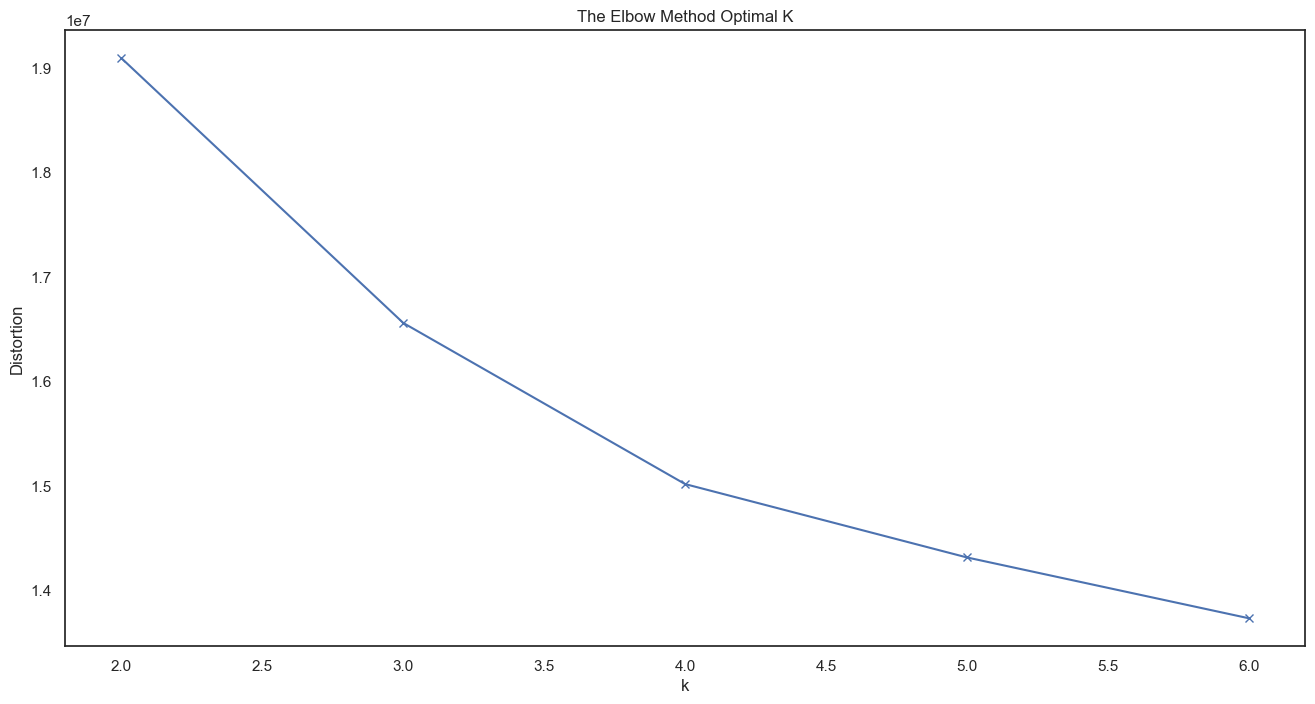

In [238]:
# Let's plot the the elbow plot

plt.figure(figsize=(16, 8))                                           

plt.plot(K, distortions, "bx-")                                       

plt.xlabel("k")                                                      

plt.ylabel("Distortion")                                            

plt.title("The Elbow Method Optimal K")                   
plt.show()

In [239]:
from sklearn.metrics import silhouette_score



In [240]:
sil_score =[]

In [287]:
kmeanModel = KMeans(init="k-means++", n_clusters=3,random_state=42)
t0 = time.time()
kmeanModel.fit(paclust_scaled)
fit_time = time.time() - t0
results = [name, fit_time, kmeanModel.inertia_]
print('Results:  Name: ',results[0],'  Time: ', results[1],'   Inertia: ', results[2])
labels = kmeanModel.labels_


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  66.21157002449036    Inertia:  16562164.91859047


In [288]:
len(labels)


3288597

In [289]:
entries_all['Cluster'] = labels
paclust['Cluster'] = labels



## Visualizamos

In [40]:
def histxvar(df,col):

    for i in range(4):
        plt.hist(df.loc[df['Cluster'] == i, col], alpha=0.5, label='Cluster {}'.format(i))
        plt.legend()
    plt.show()



In [292]:
graf = entries_all.copy()

In [293]:
graf['ProfesionS'] = graf['Profesion']
# Reemplazar los valores de la columna "Profesion" correspondientes a las categorías "Empleados", "Funcionarios", "Tecnicos", "Agricultores", "Obreros" y "Marinos" por el valor "Trabajadores"
graf['ProfesionS'] = graf['ProfesionS'].replace(['Empleados', 'Funcionarios', 'Tecnicos', 'Agricultores', 'Obreros', 'Marinos', 'Profesores'], 'Trabajadores')
graf['ProfesionS'] = graf['ProfesionS'].replace(['Sacerdotes'], 'Religiosas/os')

In [294]:
graf['Fecha'] = pd.to_datetime(graf['Fecha'], format='%Y-%m-%d')



In [295]:
graf['Dialv'] = graf['Fecha'].dt.day_name()
graf['Año'] = graf['Fecha'].dt.year




In [296]:
graf.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster,ProfesionS
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,1,Jubilados
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,1,Jubilados
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,1,Liberales
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday,1,Trabajadores
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday,1,Trabajadores


In [297]:
paclust.head()

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday,Cluster
0,0.937955,0.244722,0.330714,-3.059544,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,1.175386,0.188674,0.053846,-3.059544,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,0.700524,0.154410,0.122155,-3.059544,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,0.106946,0.154410,0.122155,-3.059544,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,1.294101,0.141167,0.167176,-3.059544,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


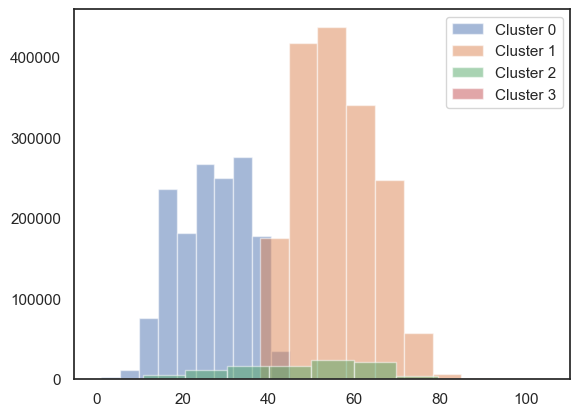

In [298]:
histxvar(graf,'Edad')

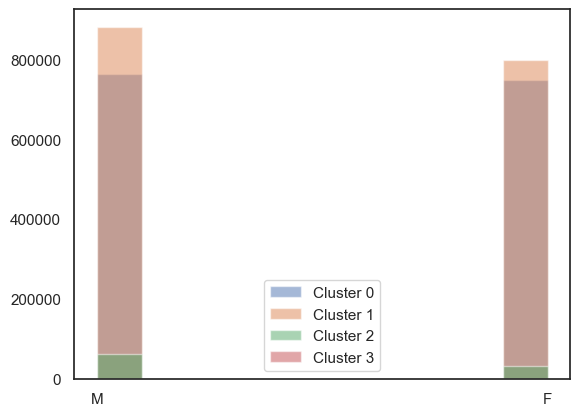

In [299]:
histxvar(graf,'Sexo')

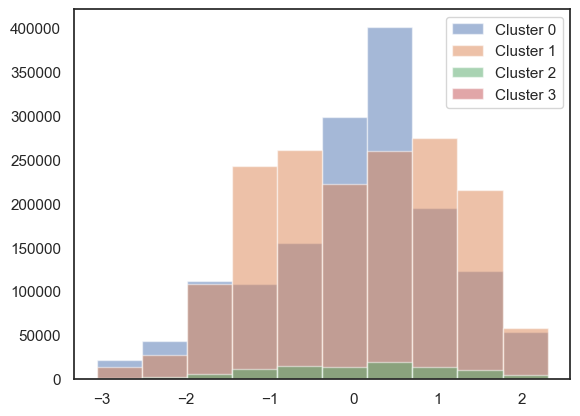

In [300]:
histxvar(paclust,'Mes')

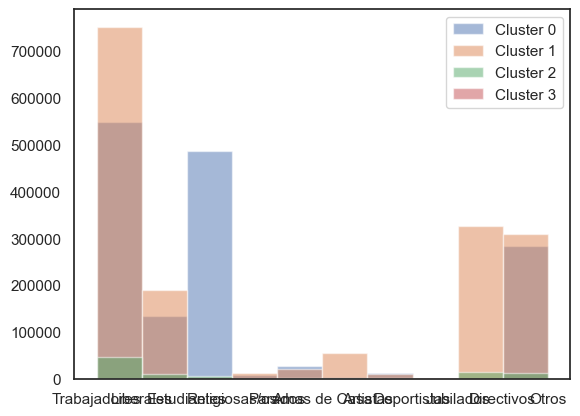

In [301]:
histxvar(graf, 'ProfesionS')

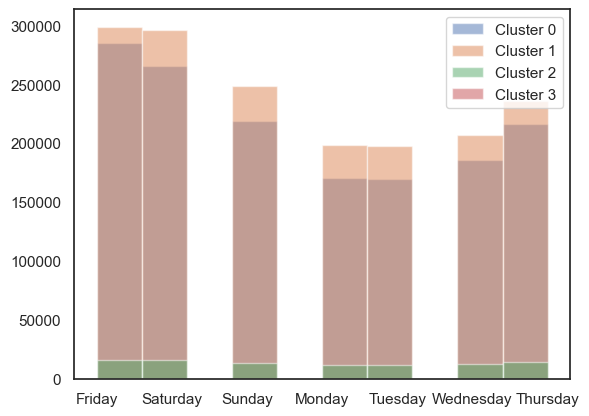

In [302]:
histxvar(graf, 'Dialv')

In [316]:
graf.Año.min()

2010

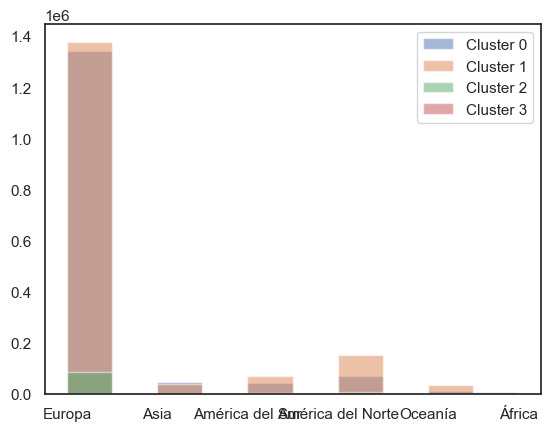

In [309]:
histxvar(graf, 'Continente')

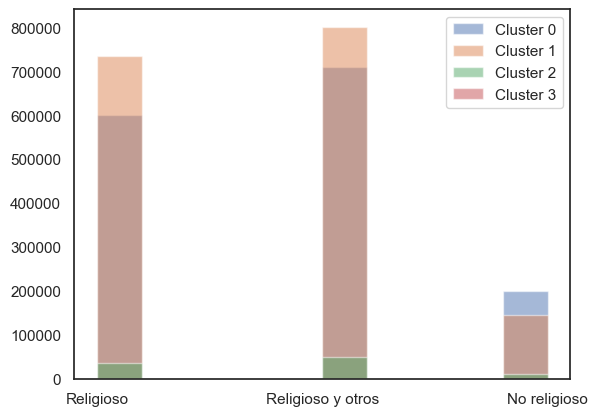

In [310]:
histxvar(graf, 'Motivo')

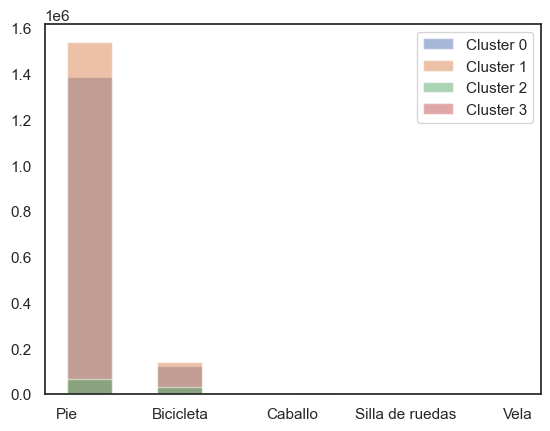

In [311]:
histxvar(graf, 'Medio')

In [312]:
graf.head(1)

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster,ProfesionS
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,1,Jubilados


0          True
1          True
2          True
3          True
4          True
           ... 
3288592    True
3288593    True
3288594    True
3288595    True
3288596    True
Name: Latitud, Length: 3288597, dtype: bool

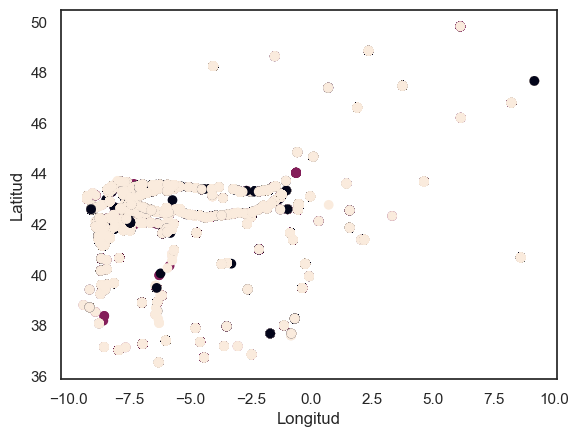

In [266]:
filtro_longitud = (graf['Longitud'] >= -20) & (graf['Longitud'] <= 10)
filtro_latitud = (graf['Latitud'] >= 30) & (graf['Latitud'] <= 50)

y = graf[filtro_latitud & filtro_longitud]['Latitud']
x = graf[filtro_latitud & filtro_longitud]['Longitud']

plt.scatter(x, y, c=labels[filtro_latitud & filtro_longitud])
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

In [267]:
camino_counts = entries_all['Camino'].value_counts()

In [268]:
top7 = camino_counts.head(4)

In [269]:
lista7 = top7.index.tolist()
entries_filtrado = entries_all[entries_all['Camino'].isin(lista7)]


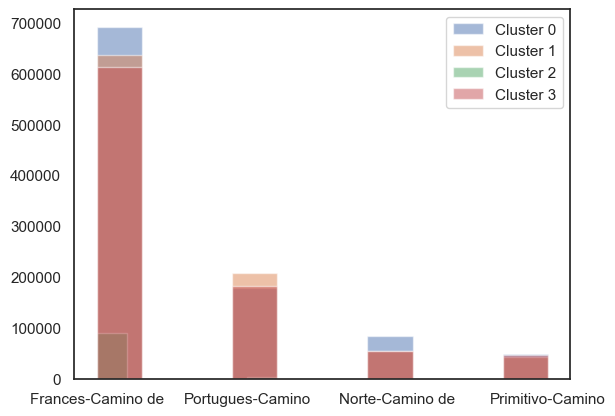

In [270]:
histxvar(entries_filtrado, 'Camino')

## PCA

In [271]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import seaborn as sns


In [272]:
paclust_scaled = paclust_scaled.drop(columns="Cluster", axis=1)
paclust_scaled.head()

,Edad,Latitud,Longitud,Mes,Sexo_F,Sexo_M,ProfesionS_Amas de Casa,ProfesionS_Artistas,ProfesionS_Deportistas,ProfesionS_Directivos,...,Continente_Europa,Continente_Oceanía,Continente_África,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,0.937955,0.244722,0.330714,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,1.175386,0.188674,0.053846,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2,0.700524,0.154410,0.122155,-3.059544,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,0.106946,0.154410,0.122155,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
4,1.294101,0.141167,0.167176,-3.059544,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


In [273]:
pca = PCA(n_components=2)



In [274]:
reduced_data = pca.fit_transform(paclust_scaled)



In [275]:
components = pca.components_


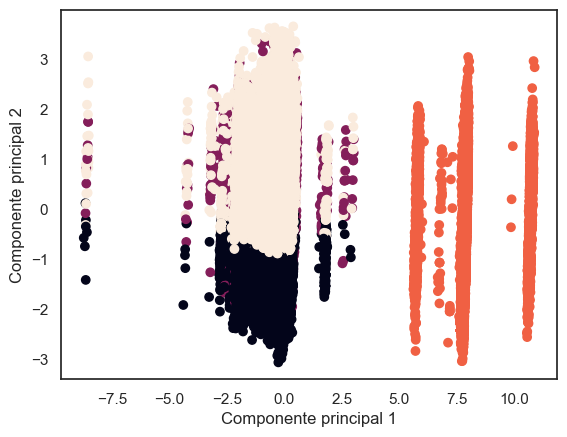

(3288597, 2)

In [276]:
# Definimos los valores de las dos primeras componentes principales
x = reduced_data[:, 0]
y = reduced_data[:, 1]


plt.scatter(x, y, c=labels)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()


reduced_data.shape

In [277]:
cols= paclust_scaled.columns.to_list()

In [278]:
# Obtener nombres de las variables
var_names = paclust_scaled.columns.to_list()

# Imprimir variables en cada componente
for i, comp in enumerate(components):
    print(f"Componente {i+1}:")
    vars_comp = [var_names[j] for j, w in enumerate(comp) if abs(w) > 0.3]
    print(vars_comp)

Componente 1:
['Latitud', 'Longitud']
Componente 2:
['Edad']


In [279]:
entries_all.head(3)

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,1
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,1
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,1


In [280]:
entries_all.to_csv('Treated_csv/entries_all_with_labels.csv', index=False)



In [283]:
reduced_data =pd.DataFrame(reduced_data)
reduced_data

,0,1
0,-0.318320,0.531955
1,-0.042951,0.740113
2,-0.092266,0.172887
3,-0.146611,-0.404122
4,-0.166929,0.846845
...,...,...
3288592,0.363068,1.168097
3288593,0.360306,1.112169
3288594,0.285733,-0.397895
3288595,0.252589,-1.069034


In [284]:
 reduced_data.to_csv('Treated_csv/PCA_Mundial.csv', index=False)



In [3]:
clusteval_raw = pd.read_csv('Treated_csv/paclust.csv')  



In [4]:
clusteval_raw = clusteval_raw.drop(columns=["Fecha", "Autonomia", "Medio", "Motivo", "Origen","Profesion", "Dia","Año","Etapa"], axis=1)
clusteval_raw.head(2)

,Sexo,Edad,Continente,Pais,Camino,Latitud,Longitud,Mes,Dialv,ProfesionS
0,M,58,Europa,España,Norte,43.159566,-4.087838,1,Friday,Jubilados
1,M,62,Europa,España,Frances,42.778420,-7.414661,1,Friday,Jubilados


In [5]:
clusteval_raw.shape

(3288597, 10)

In [7]:
frec_pais = clusteval_raw['Pais'].value_counts()

indices_frec_pais = frec_pais[frec_pais > 10000].index
indices_frec_pais

Index(['España', 'Italia', 'Alemania', 'Estados Unidos', 'Portugal', 'Francia',
       'Reino Unido', 'Irlanda', 'Corea', 'Brasil', 'Canadá', 'Polonia',
       'Holanda', 'Australia', 'México', 'Dinamarca', 'Bélgica', 'Argentina',
       'Austria', 'República Checa', 'Suiza', 'Colombia', 'Suecia', 'Hungría',
       'Japón', 'Rusia'],
      dtype='object')

In [8]:
filtro_longitud = (clusteval_raw['Longitud'] >= -13) & (clusteval_raw['Longitud'] <= 12)
filtro_latitud = (clusteval_raw['Latitud'] >= 35) & (clusteval_raw['Latitud'] <= 46)
filtro_pais = clusteval_raw['Pais'].isin(indices_frec_pais)


In [9]:
clusteval_raw_f = clusteval_raw[filtro_latitud & filtro_longitud & filtro_pais]

In [10]:
clusteval_raw.Continente.value_counts()

Europa               2802914
América del Norte     228990
América del Sur       115465
Asia                   84098
Oceanía                44494
África                 12636
Name: Continente, dtype: int64

In [11]:
clusteval_raw_f.Continente.value_counts()

Europa               2588820
América del Norte     218455
América del Sur        78307
Asia                   56572
Oceanía                36786
Name: Continente, dtype: int64

In [12]:
clusteval_raw_f.shape

(2978940, 10)

In [13]:
round((3288597-2978940)*100/3288597)

9

In [14]:

loc = Nominatim(user_agent="GetLoc")
 
# entering the location name
getLoc = loc.geocode("España")
 
# printing address
print(getLoc.address)
 
# printing latitude and longitude
print("Latitude = ", getLoc.latitude)
print("Longitude = ", getLoc.longitude)

España
Latitude =  39.3260685
Longitude =  -4.8379791


In [15]:
def latitude(texto):
    if texto in cache:
        return cache[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            latitud = getLoc.latitude
            cache[texto] = latitud
            return latitud
        else:
            return None
    except:
        return None



In [16]:
def longitud(texto):
    if texto in cache2:
        return cache2[texto]
    
    try: 
        # ingresar el nombre de la ubicación
        getLoc = loc.geocode(texto)
        if getLoc is not None:
            longitude = getLoc.longitude
            cache2[texto] = longitude
            return longitude
        else:
            return None
    except:
        return None

In [17]:
def incluir_en_cache(valores):
    l = len(valores)
    print("Estimacion: ", l/60, " minutos")
    for ele in valores:
        inicio = time.time()
        latitude(ele)
        longitud(ele)
        print(ele)
        fin = time.time()
        print(fin-inicio)

In [18]:
unique_vals = clusteval_raw_f.Pais.unique()


In [19]:
cache ={}
cache2 = {}

In [20]:
longitud('España')

-4.8379791

In [21]:
incluir_en_cache(unique_vals)

Estimacion:  0.43333333333333335  minutos
España
0.1315140724182129
Alemania
1.0070469379425049
Italia
1.1263821125030518
Portugal
0.9223287105560303
Francia
1.0223629474639893
Corea
0.9211719036102295
Japón
1.0240387916564941
Suiza
1.0243349075317383
México
1.0236620903015137
Austria
0.9162540435791016
Brasil
1.0305862426757812
Reino Unido
1.0226728916168213
Polonia
0.9342918395996094
Colombia
1.0122313499450684
Hungría
0.9744892120361328
Estados Unidos
1.0737617015838623
República Checa
1.024280071258545
Holanda
0.921504020690918
Irlanda
1.0240399837493896
Bélgica
1.023928165435791
Australia
1.0239930152893066
Argentina
1.0239567756652832
Dinamarca
0.872199296951294
Canadá
1.0732550621032715
Suecia
1.0240709781646729
Rusia
0.9217338562011719


In [22]:
def add_coords_to_dataframe_P(df, lat_dict, long_dict):
    df['Latitud_P'] = df['Pais'].map(lat_dict)
    df['Longitud_P'] = df['Pais'].map(long_dict)
    return df

In [23]:
clusteval_pre = add_coords_to_dataframe_P(clusteval_raw_f, cache, cache2)
clusteval_pre = clusteval_pre.drop(columns=["Pais"], axis=1)
clusteval_pre = clusteval_pre.drop(clusteval_pre.loc[clusteval_pre['Latitud_P'].isna()]. index)

clusteval_pre

/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_15116/788969483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Latitud_P'] = df['Pais'].map(lat_dict)
/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_15116/788969483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Longitud_P'] = df['Pais'].map(long_dict)


,Sexo,Edad,Continente,Camino,Latitud,Longitud,Mes,Dialv,ProfesionS,Latitud_P,Longitud_P
0,M,58,Europa,Norte,43.159566,-4.087838,1,Friday,Jubilados,39.326068,-4.837979
1,M,62,Europa,Frances,42.778420,-7.414661,1,Friday,Jubilados,39.326068,-4.837979
2,M,54,Europa,Frances,42.545412,-6.593872,1,Friday,Liberales,39.326068,-4.837979
3,F,44,Europa,Frances,42.545412,-6.593872,1,Friday,Trabajadores,39.326068,-4.837979
4,F,64,Europa,Frances,42.455356,-6.052903,1,Friday,Trabajadores,51.163818,10.447831
...,...,...,...,...,...,...,...,...,...,...,...
3288592,M,56,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352
3288593,M,55,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352
3288594,M,28,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352
3288595,M,16,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352


In [24]:
clusteval_mm = clusteval_pre.copy()

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_normalize = ['Edad', 'Latitud', 'Mes','Longitud','Latitud_P', 'Longitud_P']
clusteval_mm[cols_to_normalize] = scaler.fit_transform(clusteval_mm[cols_to_normalize])
clusteval_mm.head(2)

,Sexo,Edad,Continente,Camino,Latitud,Longitud,Mes,Dialv,ProfesionS,Latitud_P,Longitud_P
0,M,0.548077,Europa,Norte,0.797670,0.294370,0.0,Friday,Jubilados,0.745591,0.417236
1,M,0.586538,Europa,Frances,0.751813,0.109603,0.0,Friday,Jubilados,0.745591,0.417236


In [26]:
def do_onehot_encoding(df, cols):
    df = pd.get_dummies(df, columns=cols)
    return df



In [27]:
clusteval_mm_oh = do_onehot_encoding(clusteval_mm, ["Sexo","Continente","Camino","Mes","ProfesionS","Dialv"])
clusteval_mm_oh = clusteval_mm_oh.drop(columns=["Sexo_F"], axis=1)


clusteval_mm_oh.head(3)

,Edad,Latitud,Longitud,Latitud_P,Longitud_P,Sexo_M,Continente_América del Norte,Continente_América del Sur,Continente_Asia,Continente_Europa,...,ProfesionS_Parados,ProfesionS_Religiosas/os,ProfesionS_Trabajadores,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,0.548077,0.797670,0.294370,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1,0.586538,0.751813,0.109603,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,0.509615,0.723778,0.155188,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [112]:
clusteval_mm_oh.to_csv('Treated_csv/clusteval_mm_oh.csv', index=False)



In [14]:
clusteval_mm_oh = pd.read_csv('Treated_csv/clusteval_mm_oh.csv')

In [146]:
clusteval_mm_oh

,Edad,Latitud,Longitud,Latitud_P,Longitud_P,Sexo_M,Continente_América del Norte,Continente_América del Sur,Continente_Asia,Continente_Europa,...,ProfesionS_Parados,ProfesionS_Religiosas/os,ProfesionS_Trabajadores,Dialv_Friday,Dialv_Monday,Dialv_Saturday,Dialv_Sunday,Dialv_Thursday,Dialv_Tuesday,Dialv_Wednesday
0,0.548077,0.797670,0.294370,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1,0.586538,0.751813,0.109603,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,0.509615,0.723778,0.155188,0.745591,0.417236,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0.413462,0.723778,0.155188,0.745591,0.417236,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
4,0.605769,0.712943,0.185233,0.864345,0.479064,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288592,0.528846,0.262048,0.013968,0.748962,0.403899,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3288593,0.519231,0.262048,0.013968,0.748962,0.403899,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3288594,0.259615,0.262048,0.013968,0.748962,0.403899,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3288595,0.144231,0.262048,0.013968,0.748962,0.403899,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


In [28]:
distortions = []                                                  
K = range(2, 10)                                                  

name = "k-means++"

for k in K:
    kmeanModel = KMeans(init="k-means++", n_clusters=k,random_state=42)
    t0 = time.time()
    kmeanModel.fit(clusteval_mm_oh)
    fit_time = time.time() - t0
    results = [name, fit_time, kmeanModel.inertia_]
    print('Results:  Name: ',results[0],'  Time: ', results[1],'   Inertia: ', results[2])
    distortions.append(kmeanModel.inertia_)    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  7.937319040298462    Inertia:  9958477.727241706


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  8.64279294013977    Inertia:  9433211.309752516


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


...

Results:  Name:  k-means++   Time:  17.15401816368103    Inertia:  8277012.581716377


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  19.827919006347656    Inertia:  8049894.546155507


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  24.919996976852417    Inertia:  7959255.565924876


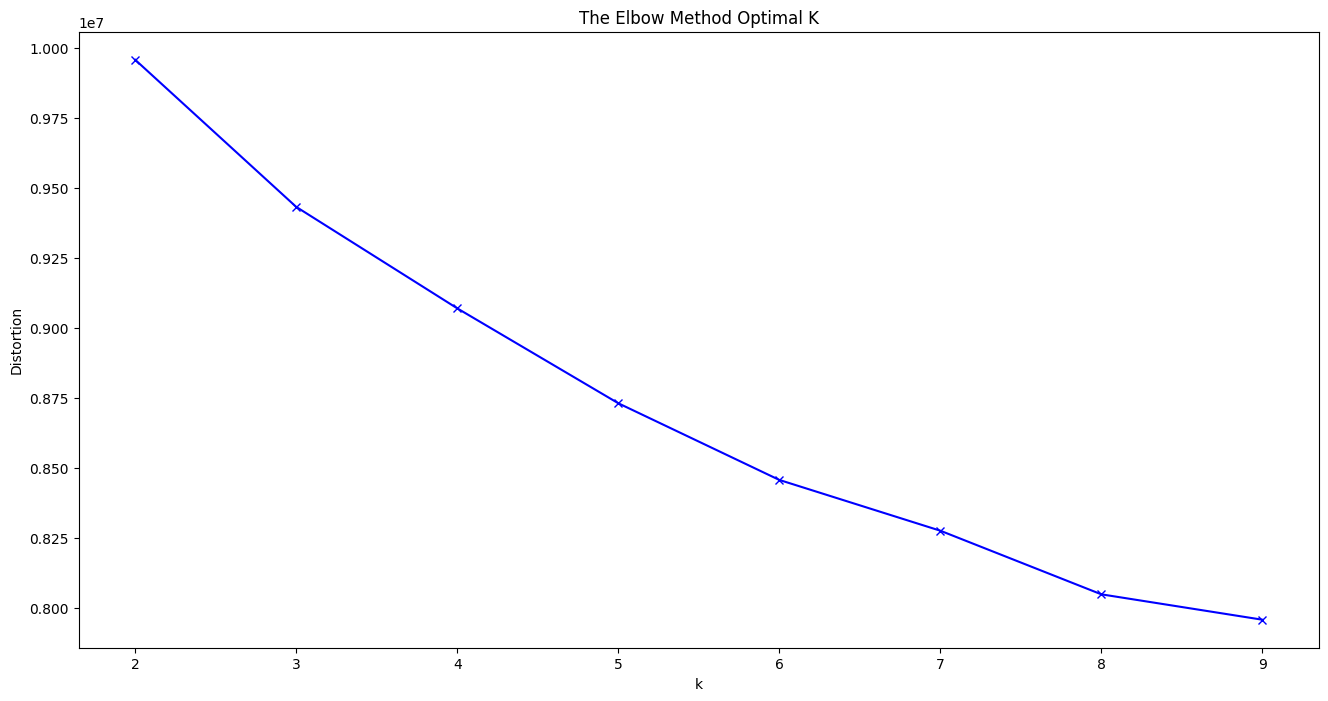

In [29]:
# Let's plot the the elbow plot

plt.figure(figsize=(16, 8))                                           

plt.plot(K, distortions, "bx-")                                       

plt.xlabel("k")                                                      

plt.ylabel("Distortion")                                            

plt.title("The Elbow Method Optimal K")                   
plt.show()

In [30]:
    kmeanModel = KMeans(init="k-means++", n_clusters=3,random_state=42)
    t0 = time.time()
    kmeanModel.fit(clusteval_mm_oh)
    fit_time = time.time() - t0
    results = [name, fit_time, kmeanModel.inertia_]
    print('Results:  Name: ',results[0],'  Time: ', results[1],'   Inertia: ', results[2])
    distortions.append(kmeanModel.inertia_)    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Results:  Name:  k-means++   Time:  8.963325262069702    Inertia:  9433211.309752516


In [31]:
labels = kmeanModel.labels_

In [32]:
len(labels)

2978940

In [33]:
len(clusteval_pre)

2978940

In [34]:
clusteval_pre['Cluster']=labels

In [35]:
clusteval_pre

,Sexo,Edad,Continente,Camino,Latitud,Longitud,Mes,Dialv,ProfesionS,Latitud_P,Longitud_P,Cluster
0,M,58,Europa,Norte,43.159566,-4.087838,1,Friday,Jubilados,39.326068,-4.837979,1
1,M,62,Europa,Frances,42.778420,-7.414661,1,Friday,Jubilados,39.326068,-4.837979,2
2,M,54,Europa,Frances,42.545412,-6.593872,1,Friday,Liberales,39.326068,-4.837979,2
3,F,44,Europa,Frances,42.545412,-6.593872,1,Friday,Trabajadores,39.326068,-4.837979,0
4,F,64,Europa,Frances,42.455356,-6.052903,1,Friday,Trabajadores,51.163818,10.447831,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3288592,M,56,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352,1
3288593,M,55,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352,1
3288594,M,28,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352,1
3288595,M,16,Europa,Portugues,38.707751,-9.136592,12,Saturday,Otros,39.662165,-8.135352,1


In [36]:
clusteval_pre.to_csv('Treated_csv/clust_mundial.csv', index=False)



In [37]:
import joblib

joblib.dump(kmeanModel, "clust_mundial_model.joblib")

# model = joblib.load("model.joblib")


['clust_mundial_model.joblib']

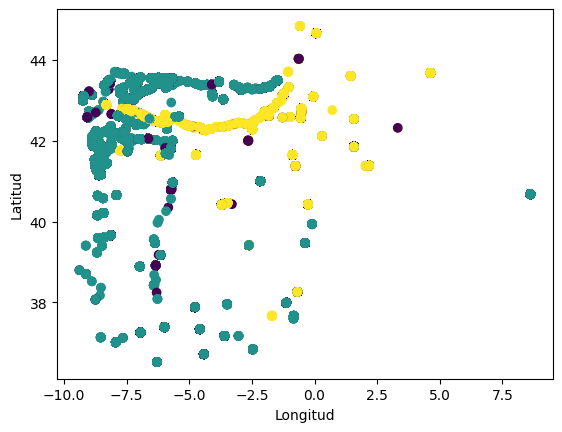

In [38]:
filtro_longitud = (clusteval_pre['Longitud'] >= -20) & (clusteval_pre['Longitud'] <= 10)
filtro_latitud = (clusteval_pre['Latitud'] >= 30) & (clusteval_pre['Latitud'] <= 50)

y = clusteval_pre[filtro_latitud & filtro_longitud]['Latitud']
x = clusteval_pre[filtro_latitud & filtro_longitud]['Longitud']

plt.scatter(x, y, c=labels[filtro_latitud & filtro_longitud])
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

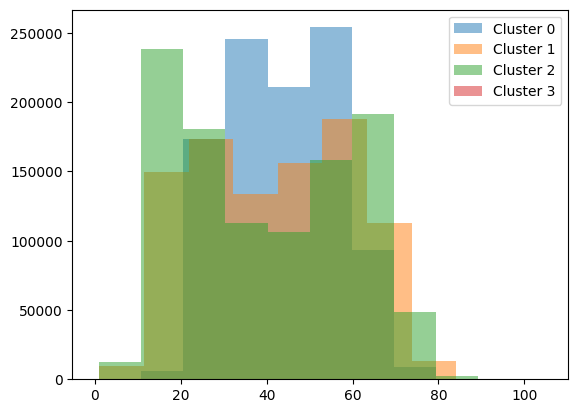

In [41]:
histxvar(clusteval_pre,'Edad')

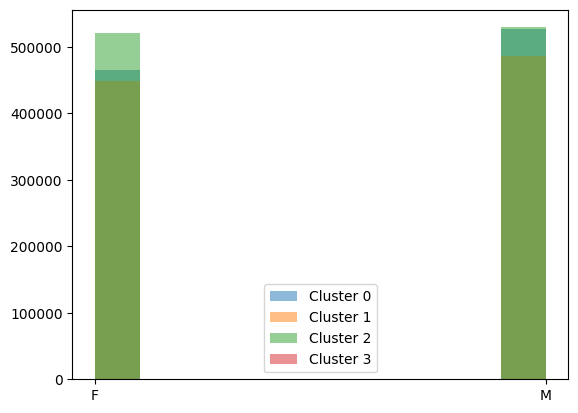

In [42]:
histxvar(clusteval_pre,'Sexo')

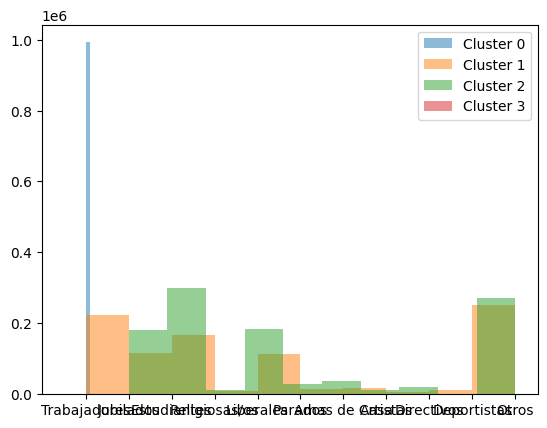

In [43]:
histxvar(clusteval_pre,'ProfesionS')

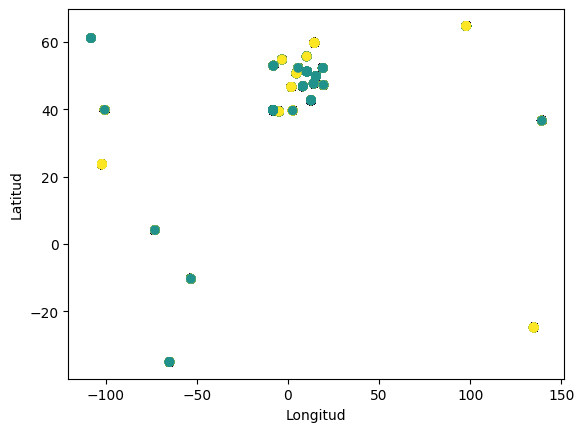

In [44]:

y = clusteval_pre['Latitud_P']
x = clusteval_pre['Longitud_P']

plt.scatter(x, y, c=labels)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

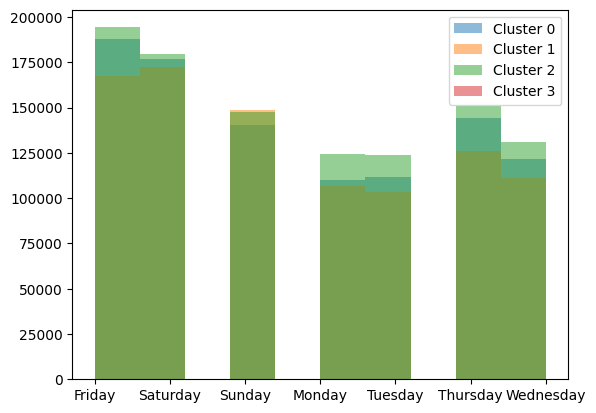

In [45]:
histxvar(clusteval_pre,'Dialv')

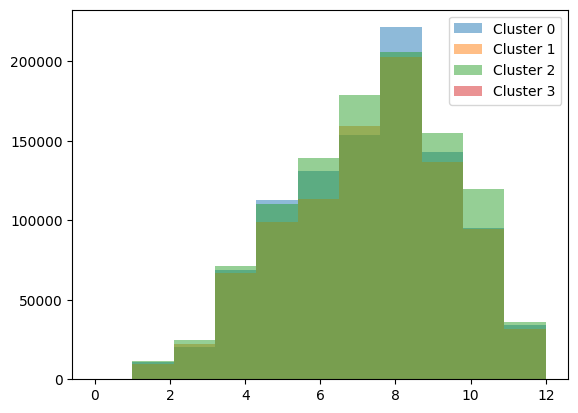

In [46]:
histxvar(clusteval_pre,'Mes')

In [101]:
def profiling(df):
    df = df.copy()
    for i in range(3):
        cluster = df.loc[df['Cluster'] == i ]
        edad = cluster.Edad.mean()
        sexo = cluster.Sexo.value_counts().index.tolist()
        pais = cluster.Pais.value_counts().index.tolist()
        medio = cluster.Medio.value_counts().index.tolist()
        motivo = cluster.Motivo.value_counts().index.tolist()
        camino = cluster.Camino.value_counts().index.tolist()
        origen = cluster.Origen.value_counts().index.tolist()
        profesion = cluster.Profesion.value_counts().index.tolist()
        mes = cluster.Mes.value_counts().index.tolist()

        print("El perfil del Cluster", i, "hace referencia a una persona de: \n ",'Edad:',round(edad), 'años \n', 'Sexo:',sexo[0] , '\n', 'Profesión:', profesion[0],'\n', 'Residencia:', pais[0], '\n', 'Medio de traslado:', medio[0], '\n', 'Motivo:', motivo[0], '\n', 'Camino realizado:', camino[0], '\n', 'Origen:', origen[0], '\n', 'Mes de viaje:', mes[:3])
    
    return None







In [63]:
def invert_dict(dictionary):
    inverted_dict = {value: key for key, value in dictionary.items()}
    return inverted_dict

# Ejemplo de uso

inverted_dict = invert_dict(cache)


In [64]:
def add_pais_to_dataframe(df, lat_dict, long_dict):
    df = df.copy()
    
    df['Pais'] = df['Latitud_P'].map(lat_dict)
    
    return df


In [ ]:
def add_origen_to_dataframe(df, lat_dict, long_dict):
    df = df.copy()
    
    df['Origen'] = df['Latitud'].map(lat_dict)
    
    return df

In [66]:
clusteval_pre = add_pais_to_dataframe(clusteval_pre, inverted_dict, inverted_dict)

In [75]:
clusteval_pre.columns

Index(['Sexo', 'Edad', 'Continente', 'Camino', 'Latitud', 'Longitud', 'Mes',
       'Dialv', 'ProfesionS', 'Latitud_P', 'Longitud_P', 'Cluster', 'Pais'],
      dtype='object')

In [78]:
clus = clusteval_pre.drop(columns = ['Sexo', 'Edad', 'Continente', 'Camino', 'Latitud', 'Longitud', 'Mes',
       'Dialv', 'ProfesionS', 'Latitud_P', 'Longitud_P', 'Pais'])
clus.head(50)

,Cluster
0,1
1,2
2,2
3,0
4,0
5,2
6,0
7,2
8,0
9,2


In [89]:
entries_all = pd.read_csv('Treated_csv/entries_all_with_labels.csv')

entries_all.head(50)

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,1
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,1
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,1
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday,1
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday,1
5,2010-01-01,F,65,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Jubilados,42.455356,-6.052903,2010,1,1,Friday,1
6,2010-01-01,M,34,Europa,Italia,NaN,Pie,Religioso,Frances-Camino de,Sarria,Empleados,42.778420,-7.414661,2010,1,1,Friday,1
7,2010-01-01,M,36,Europa,Portugal,NaN,Pie,Religioso,Frances-Camino de,Sarria,Liberales,42.778420,-7.414661,2010,1,1,Friday,1
8,2010-01-01,M,43,Europa,España,Castilla la Mancha,Pie,Religioso,Frances-Camino de,Sarria,Empleados,42.778420,-7.414661,2010,1,1,Friday,1
9,2010-01-01,M,44,Europa,España,Madrid,Pie,Religioso,Frances-Camino de,Sarria,Liberales,42.778420,-7.414661,2010,1,1,Friday,1


In [90]:
entries_all = entries_all.drop(columns='Cluster')

In [91]:
entries_with_labels_fin = entries_all.merge(clus, left_index=True, right_index=True, how='left')


In [92]:
entries_with_labels_fin.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Cantabria,Jubilados,43.159566,-4.087838,2010,1,1,Friday,1.0
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,42.778420,-7.414661,2010,1,1,Friday,2.0
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,42.545412,-6.593872,2010,1,1,Friday,2.0
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,42.545412,-6.593872,2010,1,1,Friday,0.0
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados,42.455356,-6.052903,2010,1,1,Friday,0.0


In [100]:
profiling(entries_with_labels_fin)

El perfil del Cluster 0 hace referencia a una persona de: 
  Edad: 44 años 
 Sexo: M 
 Profesión: Empleados 
 Residencia: España 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Frances-Camino de 
 Origen: Sarria 
 Mes de viaje: [8, 7, 9]
El perfil del Cluster 1 hace referencia a una persona de: 
  Edad: 42 años 
 Sexo: M 
 Profesión: Otros 
 Residencia: España 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Portugues-Camino 
 Origen: Tui 
 Mes de viaje: [8, 7, 9]
El perfil del Cluster 2 hace referencia a una persona de: 
  Edad: 40 años 
 Sexo: M 
 Profesión: Estudiantes 
 Residencia: España 
 Medio de traslado: Pie 
 Motivo: Religioso y otros 
 Camino realizado: Frances-Camino de 
 Origen: Sarria 
 Mes de viaje: [8, 7, 9]


In [102]:
entries_with_labels_fin.to_csv('Treated_csv/entries_with_labels_fin.csv', index=False)

